In [2]:
# --- Import libraries ---
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier

In [8]:
# Load the Iris dataset
iris = load_iris()
X = iris.data
y = iris.target

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Initialize the Random Forest Classifier
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model
rf_classifier.fit(X_train, y_train)

# Make predictions
y_pred = rf_classifier.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=iris.target_names))

# Feature importance
feature_importance = rf_classifier.feature_importances_
feature_names = iris.feature_names
print("\nFeature Importance:")
for name, importance in zip(feature_names, feature_importance):
    print(f"{name}: {importance:.4f}")

Accuracy: 1.00

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      1.00      1.00        13
   virginica       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45


Feature Importance:
sepal length (cm): 0.1041
sepal width (cm): 0.0446
petal length (cm): 0.4173
petal width (cm): 0.4340


Accuracy of Random Forest: 1.0


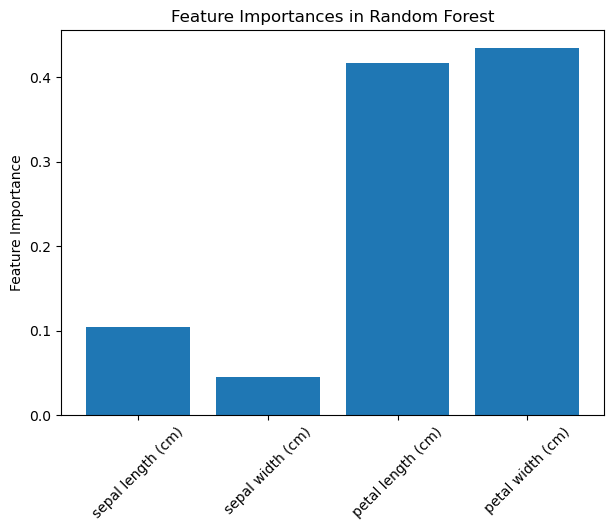

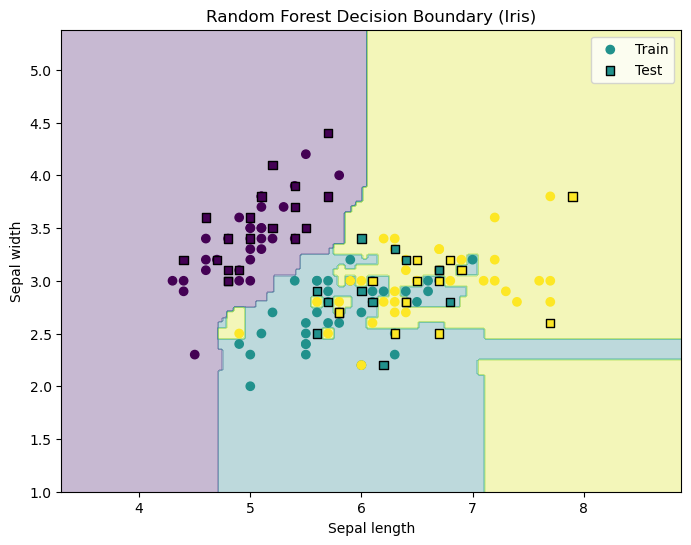

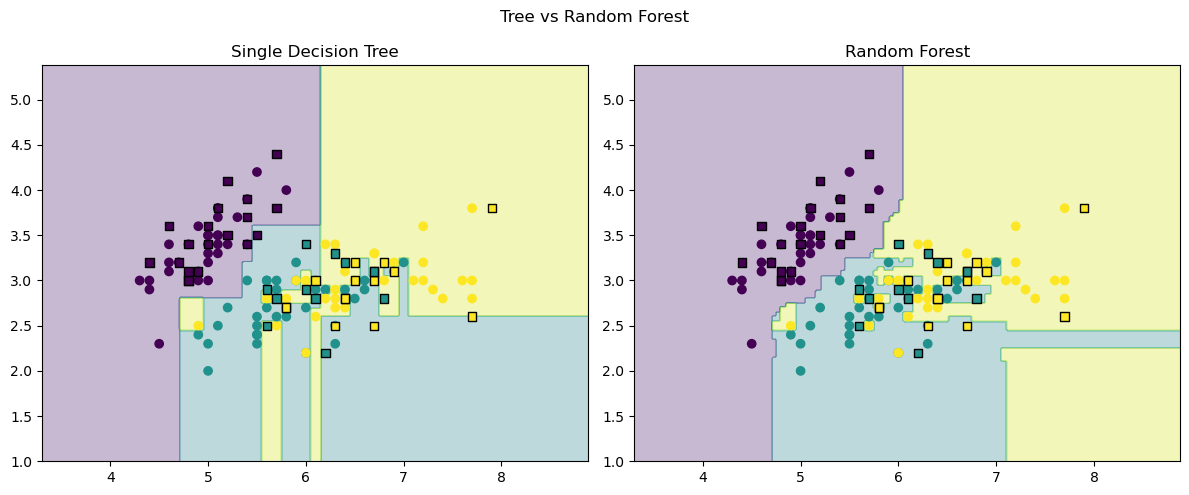

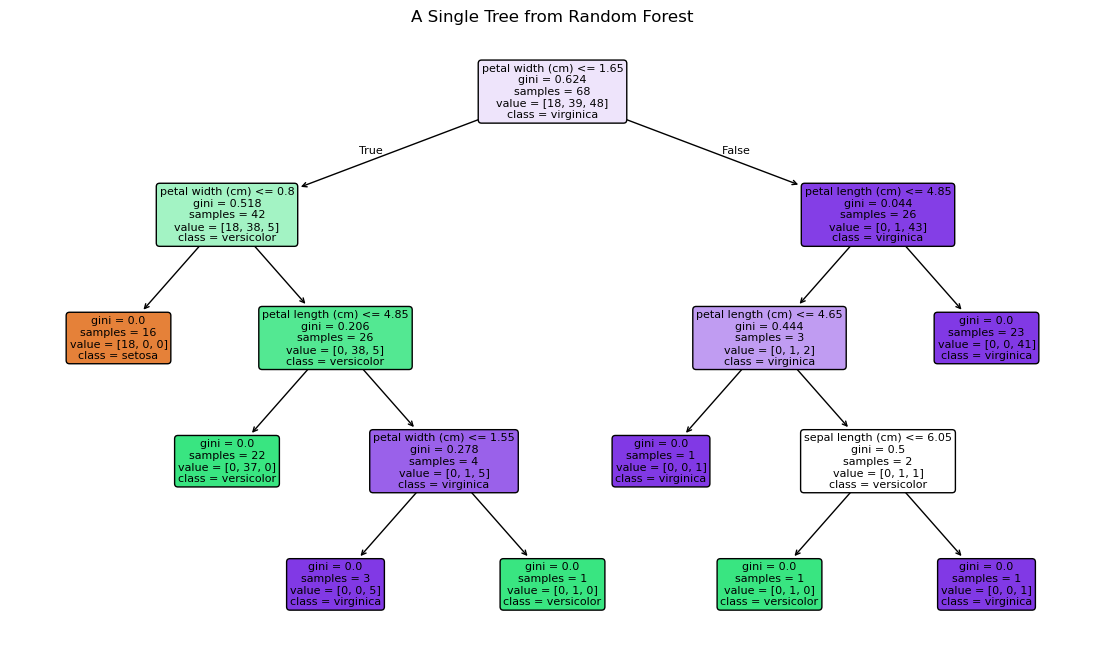

In [6]:
# --- Load Iris dataset ---
iris = load_iris()
X, y = iris.data, iris.target
feature_names = iris.feature_names

# --- Split dataset into train & test ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# --- Random Forest model ---
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)
print("Accuracy of Random Forest:", accuracy_score(y_test, y_pred))

# --- Feature importances ---
importances = rf_model.feature_importances_
plt.figure(figsize=(7, 5))
plt.bar(range(len(importances)), importances, tick_label=feature_names)
plt.ylabel("Feature Importance")
plt.title("Feature Importances in Random Forest")
plt.xticks(rotation=45)
plt.show()

# --- Decision boundary with 2 features ---
X_vis = X[:, :2]  # take only first 2 features for 2D visualization
X_train_vis, X_test_vis, y_train_vis, y_test_vis = train_test_split(X_vis, y, test_size=0.3, random_state=42)

rf_vis = RandomForestClassifier(n_estimators=100, random_state=42)
rf_vis.fit(X_train_vis, y_train_vis)

# Create mesh grid
x_min, x_max = X_vis[:, 0].min() - 1, X_vis[:, 0].max() + 1
y_min, y_max = X_vis[:, 1].min() - 1, X_vis[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

# Predict on grid
Z = rf_vis.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X_train_vis[:, 0], X_train_vis[:, 1], c=y_train_vis, marker='o', label="Train")
plt.scatter(X_test_vis[:, 0], X_test_vis[:, 1], c=y_test_vis, marker='s', edgecolor='k', label="Test")
plt.xlabel("Sepal length")
plt.ylabel("Sepal width")
plt.title("Random Forest Decision Boundary (Iris)")
plt.legend()
plt.show()

# --- Compare Single Tree vs Random Forest ---
# Train a single decision tree
tree_model = DecisionTreeClassifier(random_state=42)
tree_model.fit(X_train_vis, y_train_vis)

Z_tree = tree_model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
Z_rf = rf_vis.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.contourf(xx, yy, Z_tree, alpha=0.3)
plt.scatter(X_train_vis[:, 0], X_train_vis[:, 1], c=y_train_vis, marker='o')
plt.scatter(X_test_vis[:, 0], X_test_vis[:, 1], c=y_test_vis, marker='s', edgecolor='k')
plt.title("Single Decision Tree")

plt.subplot(1, 2, 2)
plt.contourf(xx, yy, Z_rf, alpha=0.3)
plt.scatter(X_train_vis[:, 0], X_train_vis[:, 1], c=y_train_vis, marker='o')
plt.scatter(X_test_vis[:, 0], X_test_vis[:, 1], c=y_test_vis, marker='s', edgecolor='k')
plt.title("Random Forest")

plt.suptitle("Tree vs Random Forest")
plt.tight_layout()
plt.show()

# --- Show one tree from the forest ---
plt.figure(figsize=(14, 8))
plot_tree(rf_model.estimators_[0], feature_names=feature_names,
          class_names=iris.target_names, filled=True, rounded=True, fontsize=8)
plt.title("A Single Tree from Random Forest")
plt.show()


AdaBoost Accuracy: 0.607
Gradient Boosting Accuracy: 0.728


C:\Users\lenovo\miniconda3\envs\numpy_course\Lib\site-packages\xgboost\training.py:183: UserWarning: [16:12:05] WARNING: D:\bld\xgboost-split_1755048450370\work\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Accuracy: 0.765
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000428 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5100
[LightGBM] [Info] Number of data points in the train set: 1400, number of used features: 20
[LightGBM] [Info] Start training from score -1.100042
[LightGBM] [Info] Start training from score -1.093625
[LightGBM] [Info] Start training from score -1.102190


C:\Users\lenovo\miniconda3\envs\numpy_course\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM Accuracy: 0.780
CatBoost Accuracy: 0.783


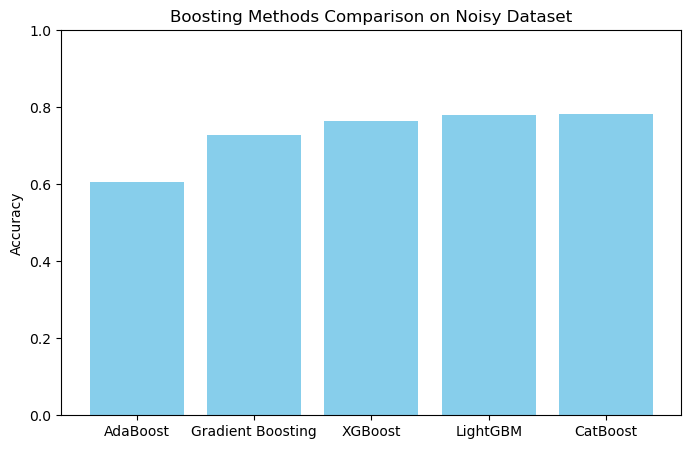

In [3]:


# External boosting libraries (install with conda or pip if missing)
try:
    from xgboost import XGBClassifier
    xgb_available = True
except ImportError:
    xgb_available = False

try:
    from lightgbm import LGBMClassifier
    lgbm_available = True
except ImportError:
    lgbm_available = False

try:
    from catboost import CatBoostClassifier
    catboost_available = True
except ImportError:
    catboost_available = False

# --- Generate harder dataset ---
X, y = make_classification(
    n_samples=2000,    # تعداد نمونه‌ها
    n_features=20,     # تعداد ویژگی‌ها
    n_informative=10,  # ویژگی‌های مفید
    n_redundant=5,     # ویژگی‌های وابسته
    n_classes=3,       # سه کلاس
    flip_y=0.1,        # 10% نویز در برچسب‌ها
    class_sep=1.0,     # جدایی کلاس‌ها (کم = سخت‌تر)
    random_state=42
)

# Split train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# --- Define models ---
models = {
    "AdaBoost": AdaBoostClassifier(n_estimators=200, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=200, random_state=42),
}

if xgb_available:
    models["XGBoost"] = XGBClassifier(n_estimators=200, use_label_encoder=False, eval_metric="mlogloss", random_state=42)

if lgbm_available:
    models["LightGBM"] = LGBMClassifier(n_estimators=200, random_state=42)

if catboost_available:
    models["CatBoost"] = CatBoostClassifier(iterations=200, verbose=0, random_state=42)

# --- Train & Evaluate ---
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f"{name} Accuracy: {acc:.3f}")

# --- Visualization ---
plt.figure(figsize=(8,5))
plt.bar(results.keys(), results.values(), color='skyblue')
plt.ylabel("Accuracy")
plt.title("Boosting Methods Comparison on Noisy Dataset")
plt.ylim(0,1)
plt.show()


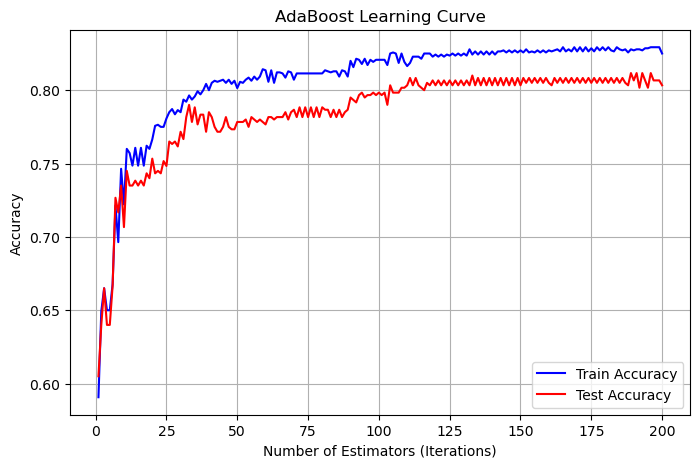

In [4]:

# --- Generate a more difficult dataset with noise ---
X, y = make_classification(
    n_samples=2000, n_features=20, n_informative=10,
    n_redundant=5, n_classes=2, flip_y=0.1, class_sep=0.8,
    random_state=42
)

# Split train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# --- Train AdaBoost with many estimators ---
n_estimators = 200
model = AdaBoostClassifier(n_estimators=n_estimators, random_state=42)
model.fit(X_train, y_train)

# --- Track accuracy at each iteration ---
train_scores = []
test_scores = []

for y_train_pred, y_test_pred in zip(model.staged_predict(X_train), model.staged_predict(X_test)):
    train_scores.append(accuracy_score(y_train, y_train_pred))
    test_scores.append(accuracy_score(y_test, y_test_pred))

# --- Plot learning curve ---
plt.figure(figsize=(8,5))
plt.plot(range(1, n_estimators+1), train_scores, label="Train Accuracy", color="blue")
plt.plot(range(1, n_estimators+1), test_scores, label="Test Accuracy", color="red")
plt.xlabel("Number of Estimators (Iterations)")
plt.ylabel("Accuracy")
plt.title("AdaBoost Learning Curve")
plt.legend()
plt.grid(True)
plt.show()


Underfit (n_estimators=5, depth=1) -> Train: 0.615, Test: 0.572
Good Fit (n_estimators=100, depth=3) -> Train: 0.870, Test: 0.705
Overfit (n_estimators=800, depth=6) -> Train: 1.000, Test: 0.718


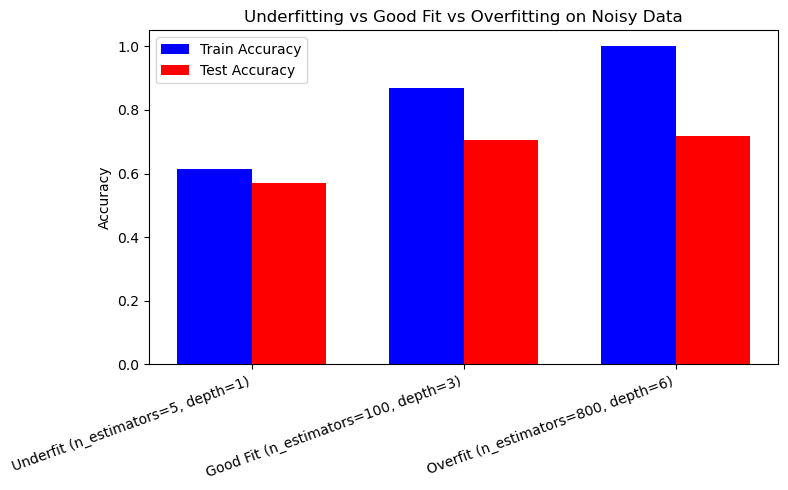

In [7]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score

# --- Create very noisy dataset (hard to generalize) ---
X, y = make_classification(
    n_samples=2000, n_features=20, n_informative=5, 
    n_redundant=5, n_classes=2, flip_y=0.3, class_sep=0.5, random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# --- Models with different complexity ---
models = {
    "Underfit (n_estimators=5, depth=1)": GradientBoostingClassifier(n_estimators=5, max_depth=1, random_state=42),
    "Good Fit (n_estimators=100, depth=3)": GradientBoostingClassifier(n_estimators=100, max_depth=3, random_state=42),
    "Overfit (n_estimators=800, depth=6)": GradientBoostingClassifier(n_estimators=800, max_depth=10, random_state=42),
}

train_acc = []
test_acc = []

for name, model in models.items():
    model.fit(X_train, y_train)
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    train_acc.append(accuracy_score(y_train, train_pred))
    test_acc.append(accuracy_score(y_test, test_pred))
    print(f"{name} -> Train: {train_acc[-1]:.3f}, Test: {test_acc[-1]:.3f}")

# --- Visualization ---
plt.figure(figsize=(8,5))
bar_width = 0.35
indices = range(len(models))

plt.bar([i-bar_width/2 for i in indices], train_acc, width=bar_width, label="Train Accuracy", color="blue")
plt.bar([i+bar_width/2 for i in indices], test_acc, width=bar_width, label="Test Accuracy", color="red")

plt.xticks(indices, models.keys(), rotation=20, ha="right")
plt.ylabel("Accuracy")
plt.title("Underfitting vs Good Fit vs Overfitting on Noisy Data")
plt.legend()
plt.tight_layout()
plt.show()
